In [1]:
!pip install sentencepiece 


In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from transformers import AutoTokenizer
from datasets import load_dataset
SEED = 42
np.random.seed(SEED)

In [2]:
# Загрузка датасета с HuggingFace
print('Загружаем датасет Tobi-Bueck/customer-support-tickets...')
raw_dataset = load_dataset('Tobi-Bueck/customer-support-tickets', split='train')
df = raw_dataset.to_pandas()

print(f'Размер датасета: {len(df)} строк')
print(f'Колонки: {df.columns.tolist()}')
df.head(3)

Загружаем датасет Tobi-Bueck/customer-support-tickets...


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

Размер датасета: 61765 строк
Колонки: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None


In [3]:
with open('/kaggle/input/datasets/alinaokhina/homework1/train_idx.txt') as f:
    train_idx = [int(x) for x in f.read().strip().split('\n')]

with open('/kaggle/input/datasets/alinaokhina/homework1/val_idx.txt') as f:
    val_idx = [int(x) for x in f.read().strip().split('\n')]

with open('/kaggle/input/datasets/alinaokhina/homework1/test_idx.txt') as f:
    test_idx = [int(x) for x in f.read().strip().split('\n')]

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val   = df.iloc[val_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

print(len(df_train))
print(len(df_val))
print(len(df_test))

49412
6176
6177


# работа с данными

In [4]:
# очистка
df_train['subject'] = df_train['subject'].fillna('')
df_train['body'] = df_train['body'].fillna('')

df_val['subject'] = df_val['subject'].fillna('')
df_val['body'] = df_val['body'].fillna('')

df_test['subject'] = df_test['subject'].fillna('')
df_test['body'] = df_test['body'].fillna('')

In [5]:
# создаём единый текст
for d in [df_train, df_val, df_test]:
    d['text'] = "SUBJECT: " + d['subject'] + " BODY: " + d['body']

# EDA

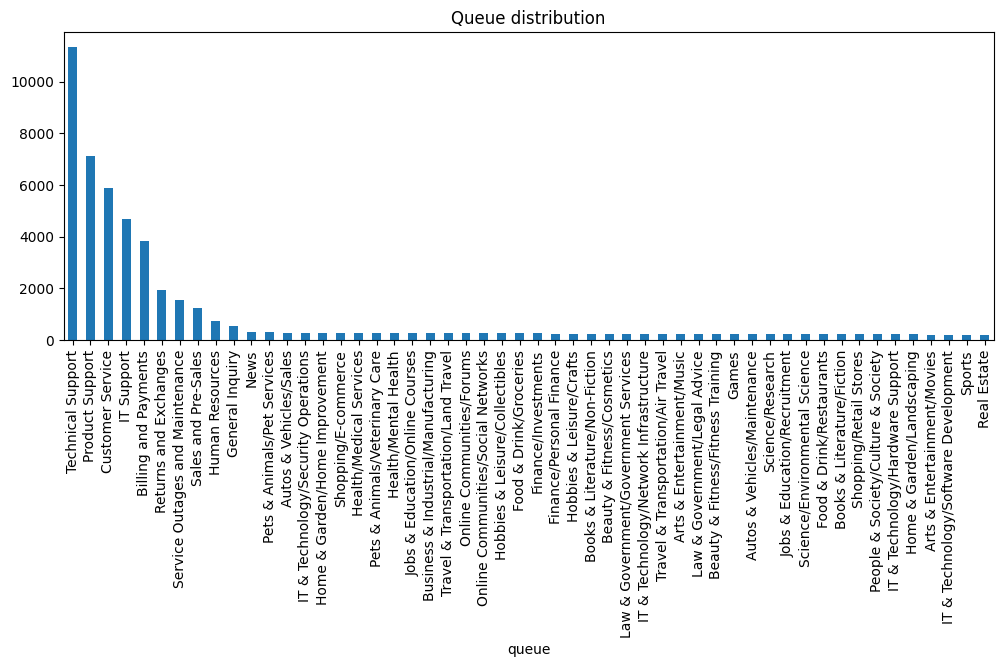

In [6]:
import matplotlib.pyplot as plt

df_train['queue'].value_counts().plot(
    kind='bar',
    figsize=(12,4)
)

plt.title("Queue distribution")
plt.show()

видим сильный дисбаланс классов, некоторые очереди встречаются значительно чаще других

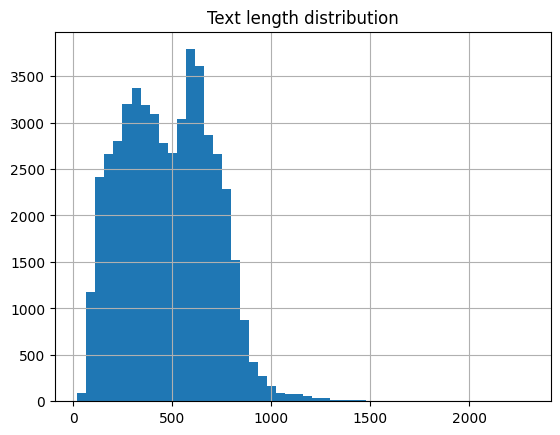

In [7]:
df_train['length'] = df_train['text'].apply(len)

df_train['length'].hist(bins=50)

plt.title("Text length distribution")
plt.show()

# Кодирование лейблов

In [8]:
queue_enc = LabelEncoder()
priority_enc = LabelEncoder()
type_enc = LabelEncoder()

df_train['queue_id'] = queue_enc.fit_transform(df_train['queue'])
df_val['queue_id'] = queue_enc.transform(df_val['queue'])
df_test['queue_id'] = queue_enc.transform(df_test['queue'])

df_train['priority_id'] = priority_enc.fit_transform(df_train['priority'])
df_val['priority_id'] = priority_enc.transform(df_val['priority'])
df_test['priority_id'] = priority_enc.transform(df_test['priority'])

df_train['type_id'] = type_enc.fit_transform(df_train['type'])
df_val['type_id'] = type_enc.transform(df_val['type'])
df_test['type_id'] = type_enc.transform(df_test['type'])

# Baseline (TF-IDF)

In [9]:
# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    stop_words="english"
)

X_train = vectorizer.fit_transform(df_train['text'])
X_val = vectorizer.transform(df_val['text'])
X_test = vectorizer.transform(df_test['text'])

In [10]:
model = LinearSVC()

model.fit(X_train, df_train['queue_id'])

LinearSVC()

In [11]:
pred_val = model.predict(X_val)

print("Macro-F1:", f1_score(df_val['queue_id'], pred_val, average='macro'))
print("Accuracy:", accuracy_score(df_val['queue_id'], pred_val))

Macro-F1: 0.8586572018373105
Accuracy: 0.6305051813471503


# Transformer

In [13]:
import torch.nn as nn


In [16]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [25]:
from torch.utils.data import Dataset

class TicketDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.texts = df['text'].tolist()
        self.queue = df['queue_id'].tolist()
        self.priority = df['priority_id'].tolist()
        self.type = df['type_id'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors=None  # <- важно: возвращаем обычный dict, а не тензоры с размерностью 1
        )
        return {
            "input_ids": torch.tensor(encoding["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(encoding["attention_mask"], dtype=torch.long),
            "queue": torch.tensor(self.queue[idx], dtype=torch.long),
            "priority": torch.tensor(self.priority[idx], dtype=torch.long),
            "type": torch.tensor(self.type[idx], dtype=torch.long)
        }

In [26]:
from torch.utils.data import DataLoader

train_dataset = TicketDataset(df_train, tokenizer)
val_dataset = TicketDataset(df_val, tokenizer)
test_dataset = TicketDataset(df_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [27]:
import torch.nn as nn
from transformers import AutoModel

class MultiTaskModel(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(0.2)
        self.queue_head = nn.Linear(hidden, 52)
        self.priority_head = nn.Linear(hidden, 5)
        self.type_head = nn.Linear(hidden, 5)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:,0,:]  # [CLS] token
        pooled = self.dropout(pooled)
        queue_logits = self.queue_head(pooled)
        priority_logits = self.priority_head(pooled)
        type_logits = self.type_head(pooled)
        return queue_logits, priority_logits, type_logits

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiTaskModel()
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
model.to(device)

criterion_queue = nn.CrossEntropyLoss(weight=queue_weights.to(device))
criterion_priority = nn.CrossEntropyLoss()
criterion_type = nn.CrossEntropyLoss()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using 2 GPUs


In [32]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(df_train['queue_id'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=df_train['queue_id'])

queue_weights = queue_weights.to(device)  # переносим на GPU
criterion_queue = nn.CrossEntropyLoss(weight=queue_weights)
criterion_priority = nn.CrossEntropyLoss()
criterion_type = nn.CrossEntropyLoss()

model = MultiTaskModel()
# Оборачиваем в DataParallel, автоматически распределяет батчи на все доступные GPU
model = nn.DataParallel(model)
model = model.to(device)  # device обычно 'cuda'



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [33]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [34]:
from tqdm import tqdm
import torch

def train_epoch(model, loader, optimizer, criterion_queue, criterion_priority, criterion_type, device):
    model.train()
    total_loss = 0
    loop = tqdm(loader, leave=True)
    
    for batch in loop:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        queue = batch["queue"].to(device)
        priority = batch["priority"].to(device)
        type_ = batch["type"].to(device)

        optimizer.zero_grad()
        queue_logits, priority_logits, type_logits = model(input_ids, attention_mask)

        loss_queue = criterion_queue(queue_logits, queue)
        loss_priority = criterion_priority(priority_logits, priority)
        loss_type = criterion_type(type_logits, type_)
        loss = 2*loss_queue + loss_priority + loss_type

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_description(f"Train Loss: {loss.item():.4f}")
    
    return total_loss / len(loader)

In [35]:
criterion_queue = nn.CrossEntropyLoss(weight=queue_weights)
criterion_priority = nn.CrossEntropyLoss()
criterion_type = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

EPOCHS = 3
for epoch in range(EPOCHS):
    print(f"\n=== Epoch {epoch+1} ===")
    avg_loss = train_epoch(model, train_loader, optimizer, 
                           criterion_queue, criterion_priority, criterion_type, device)
    print(f"Average Train Loss: {avg_loss:.4f}")


=== Epoch 1 ===


Train Loss: 2.7795: 100%|██████████| 3089/3089 [13:33<00:00,  3.80it/s]


Average Train Loss: 5.9408

=== Epoch 2 ===


Train Loss: 4.8820: 100%|██████████| 3089/3089 [13:32<00:00,  3.80it/s]


Average Train Loss: 2.9495

=== Epoch 3 ===


Train Loss: 1.6732: 100%|██████████| 3089/3089 [13:33<00:00,  3.80it/s]

Average Train Loss: 2.3373


In [36]:
from sklearn.metrics import f1_score, accuracy_score

def evaluate_queue(model, loader):
    model.eval()
    preds, targets = [], []
    loop = tqdm(loader, leave=True)
    
    with torch.no_grad():
        for batch in loop:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            queue = batch["queue"].to(device)
            
            queue_logits, _, _ = model(input_ids, attention_mask)
            pred = torch.argmax(queue_logits, dim=1)
            
            preds.extend(pred.cpu().numpy())
            targets.extend(queue.cpu().numpy())
            
            loop.set_description("Evaluating")
    
    f1 = f1_score(targets, preds, average="macro")
    acc = accuracy_score(targets, preds)
    return f1, acc

f1, acc = evaluate_queue(model, test_loader)
print("Macro F1 (queue):", f1)
print("Accuracy (queue):", acc)

Evaluating: 100%|██████████| 387/387 [00:34<00:00, 11.14it/s]

Macro F1 (queue): 0.8144285298148037
Accuracy (queue): 0.41476444876153473


In [37]:
def confidence_metric(model, loader, top_ratio=0.7):
    model.eval()
    confidences, preds, targets = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            queue = batch["queue"].to(device)

            queue_logits, _, _ = model(input_ids, attention_mask)
            probs = torch.softmax(queue_logits, dim=1)
            conf, pred = torch.max(probs, dim=1)

            confidences.extend(conf.cpu().numpy())
            preds.extend(pred.cpu().numpy())
            targets.extend(queue.cpu().numpy())

    # выбираем top_ratio по уверенности
    threshold = np.quantile(confidences, 1-top_ratio)
    mask = np.array(confidences) >= threshold
    f1 = f1_score(np.array(targets)[mask], np.array(preds)[mask], average="macro")
    acc = accuracy_score(np.array(targets)[mask], np.array(preds)[mask])
    return f1, acc

f1_conf, acc_conf = confidence_metric(model, test_loader, top_ratio=0.7)
print("Macro F1 (70% confident):", f1_conf)
print("Accuracy (70% confident):", acc_conf)

Macro F1 (70% confident): 0.8199436357001558
Accuracy (70% confident): 0.5092506938020351


# confidence анализ

In [38]:
import numpy as np
import torch
from sklearn.metrics import f1_score
from tqdm import tqdm

def confidence_analysis(model, loader):

    model.eval()

    confidences = []
    preds = []
    targets = []

    with torch.no_grad():

        for batch in tqdm(loader):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            queue = batch["queue"].to(device)

            # ВАЖНО
            with torch.cuda.amp.autocast():

                queue_logits, _, _ = model(
                    input_ids,
                    attention_mask
                )

            probs = torch.softmax(queue_logits, dim=1)

            conf, pred = torch.max(probs, dim=1)

            confidences.extend(conf.cpu().numpy())
            preds.extend(pred.cpu().numpy())
            targets.extend(queue.cpu().numpy())

    confidences = np.array(confidences)
    preds = np.array(preds)
    targets = np.array(targets)

    results = {}

    for ratio in [1.0, 0.9, 0.8, 0.7, 0.6]:

        threshold = np.quantile(confidences, 1 - ratio)

        mask = confidences >= threshold

        f1 = f1_score(
            targets[mask],
            preds[mask],
            average="macro"
        )

        results[ratio] = f1

    return results

In [39]:
import numpy as np
import torch
from sklearn.metrics import f1_score
from tqdm import tqdm

def confidence_analysis(model, loader):

    model.eval()

    confidences = []
    preds = []
    targets = []

    with torch.no_grad():

        for batch in tqdm(loader):

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            queue = batch["queue"].to(device)

            with torch.cuda.amp.autocast():

                queue_logits, _, _ = model(
                    input_ids,
                    attention_mask
                )

            probs = torch.softmax(queue_logits, dim=1)

            conf, pred = torch.max(probs, dim=1)

            confidences.extend(conf.cpu().numpy())
            preds.extend(pred.cpu().numpy())
            targets.extend(queue.cpu().numpy())

    confidences = np.array(confidences)
    preds = np.array(preds)
    targets = np.array(targets)

    results = {}

    order = np.argsort(-confidences)  # сортировка по уверенности

    for ratio in [1.0, 0.9, 0.8, 0.7, 0.6]:

        k = int(len(confidences) * ratio)

        idx = order[:k]

        f1 = f1_score(
            targets[idx],
            preds[idx],
            average="macro"
        )

        results[ratio] = f1

    return results

In [40]:
confidence_results = confidence_analysis(model, test_loader)

for k,v in confidence_results.items():
    print(f"{int(k*100)}% confident → MacroF1 = {v:.3f}")

100%|██████████| 387/387 [00:18<00:00, 20.75it/s]

100% confident → MacroF1 = 0.814
90% confident → MacroF1 = 0.816
80% confident → MacroF1 = 0.818
70% confident → MacroF1 = 0.820
60% confident → MacroF1 = 0.821


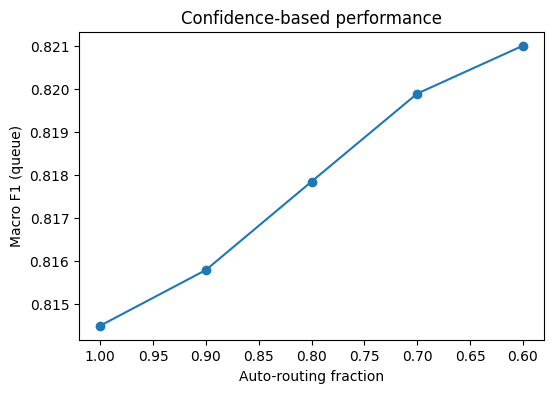

In [41]:
import matplotlib.pyplot as plt

ratios = list(confidence_results.keys())
scores = list(confidence_results.values())

plt.figure(figsize=(6,4))

plt.plot(ratios, scores, marker="o")

plt.xlabel("Auto-routing fraction")
plt.ylabel("Macro F1 (queue)")

plt.title("Confidence-based performance")

plt.gca().invert_xaxis()

plt.show()

при снижении порога уверенности скор увеличивается, как и ожидалось. выше уверенность - выше точность